In [1]:
# Importing Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV

# TensorFlow / Keras
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import SimpleRNN, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Scikeras
from scikeras.wrappers import KerasRegressor

# Random Seed
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
#  Importing the Data

df = pd.read_csv("C://Users//sekhar//Downloads//AAPL(1).csv")

print("First 5 Rows")
df.head()     # Head gives first 5 rows by default

First 5 Rows


,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.407747,117258400.0
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.386473,43971200.0
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.358108,26432000.0
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366972,21610400.0
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.377609,18362400.0


In [3]:
# Summary Statistics
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,9822.000000,9822.000000,9822.000000,9822.000000,9822.000000,9.822000e+03
mean,30.350057,30.640633,30.048298,30.352940,28.364033,8.620720e+07
std,53.443016,53.908364,52.983661,53.464270,51.603590,8.623138e+07
min,0.198661,0.198661,0.196429,0.196429,0.156008,3.472000e+05
25%,1.062500,1.085357,1.043571,1.066964,0.914089,3.318138e+07
50%,1.709286,1.742366,1.671429,1.712857,1.452872,5.798940e+07
75%,30.393928,30.555714,29.865358,30.233214,26.305946,1.076320e+08
max,267.899994,268.000000,265.390015,267.100006,267.100006,1.855410e+09


In [4]:
df.shape           

(9823, 7)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9823 entries, 0 to 9822
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9823 non-null   str    
 1   Open       9822 non-null   float64
 2   High       9822 non-null   float64
 3   Low        9822 non-null   float64
 4   Close      9822 non-null   float64
 5   Adj Close  9822 non-null   float64
 6   Volume     9822 non-null   float64
dtypes: float64(6), str(1)
memory usage: 633.3 KB


In [6]:
# Checking duplicates
df.duplicated().sum()

0

                            DATA PREPROCESSING

In [7]:
# Indentifing missing values
df.isnull().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

# Set Date as Index
df.set_index('Date', inplace=True)


In [11]:
df = df.sort_values('Date')


In [12]:
# Close price as the Target variable
data = df[['Close']]

                            SCALING

In [13]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(data)


                            CREATE SEQUENCES

In [14]:
def create_sequences(data, look_back=60, future_days=1):

    X = []
    y = []

    for i in range(look_back, len(data) - future_days + 1):

        X.append(data[i-look_back:i, 0])

        y.append(data[i + future_days - 1, 0])

    X = np.array(X)
    y = np.array(y)

    return X, y

                            PREPARE DATA

In [15]:
def prepare_data(future_days):

    look_back = 60

    X, y = create_sequences(
        scaled_data,
        look_back=look_back,
        future_days=future_days
    )

    # Reshape for RNN/LSTM
    X = X.reshape((X.shape[0], X.shape[1], 1))

    # Train-Test Split (80-20)
    train_size = int(len(X) * 0.8)

    X_train = X[:train_size]
    X_test = X[train_size:]

    y_train = y[:train_size]
    y_test = y[train_size:]

    return X_train, X_test, y_train, y_test

                            SIMPLE RNN MODEL

In [16]:
def build_simple_rnn():

    model = Sequential()

    model.add(
        SimpleRNN(
            units=50,
            return_sequences=False,
            input_shape=(60, 1)
        )
    )

    model.add(Dropout(0.2))

    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mean_squared_error'
    )

    return model

                            LSTM MODEL

In [17]:
def build_lstm(units=50, dropout_rate=0.2, learning_rate=0.001):

    model = Sequential()

    model.add(LSTM(units=units, return_sequences=False,
                   input_shape=(60,1)))

    model.add(Dropout(dropout_rate))

    model.add(Dense(1))

    optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error'
    )

    return model

                            GRID SEARCH FOR LSTM 

In [ ]:
print("\nRunning GridSearchCV for LSTM...")

# Preparing Data for 1-Day Prediction
X_train_gs, X_test_gs, y_train_gs, y_test_gs = prepare_data(1)

# Wrap Model
lstm_model = KerasRegressor(
    model=build_lstm,
    verbose=0
)

# Parameter Grid
param_grid = {

    'model__units': [32, 50],

    'model__dropout_rate': [0.2, 0.3],

    'model__learning_rate': [0.001, 0.0005],

    'batch_size': [16, 32],

    'epochs': [10]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=lstm_model,
    param_grid=param_grid,
    cv=2,
    scoring='neg_mean_squared_error'
)

grid_result = grid.fit(X_train_gs, y_train_gs)

print("\nBest Parameters")
print(grid_result.best_params_)


Running GridSearchCV for LSTM...

Best Parameters
{'batch_size': 16, 'epochs': 10, 'model__dropout_rate': 0.2, 'model__learning_rate': 0.001, 'model__units': 50}


                            TRAIN AND EVALUATE FUNCTION 


SimpleRNN MODEL - 1 DAY PREDICTION
Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.3676e-04
Epoch 1: val_loss improved from None to 0.01422, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.6461e-04 - val_loss: 0.0142
Epoch 2/50
244/245 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.2704e-05
Epoch 2: val_loss improved from 0.01422 to 0.00640, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5.5465e-05 - val_loss: 0.0064
Epoch 3/50
244/245 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.6181e-05
Epoch 3: val_loss improved from 0.00640 to 0.00074, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 3.1538e-05 - val_loss: 7.3893e-04
Epoch 4/50
244/245 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4.6998e-05
Epoch 4: val_loss did no

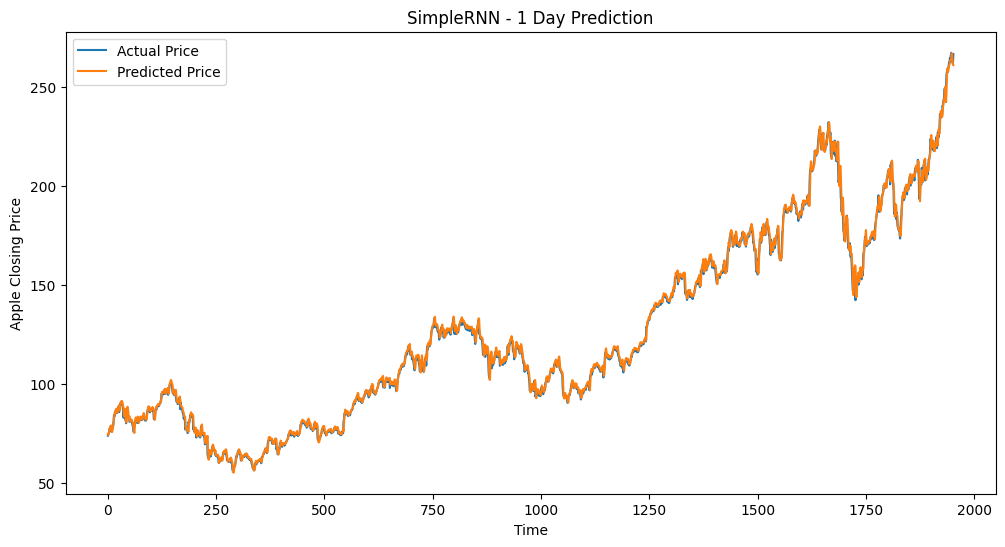


LSTM MODEL - 1 DAY PREDICTION
Epoch 1/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 5.5998e-04
Epoch 1: val_loss improved from None to 0.00036, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 1.7934e-04 - val_loss: 3.6137e-04
Epoch 2/50
243/245 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 4.2450e-05
Epoch 2: val_loss did not improve from 0.00036
245/245 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - loss: 3.5148e-05 - val_loss: 4.4487e-04
Epoch 3/50
243/245 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 2.4841e-05
Epoch 3: val_loss did not improve from 0.00036
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 2.3492e-05 - val_loss: 6.5479e-04
Epoch 4/50
245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 2.4617e-05
Epoch 4: val_loss improved from 0.00036 to 0.00028, saving model to best_model.keras

Epoch 4: finished saving model to best_model.keras
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 2.2031e-05 - 

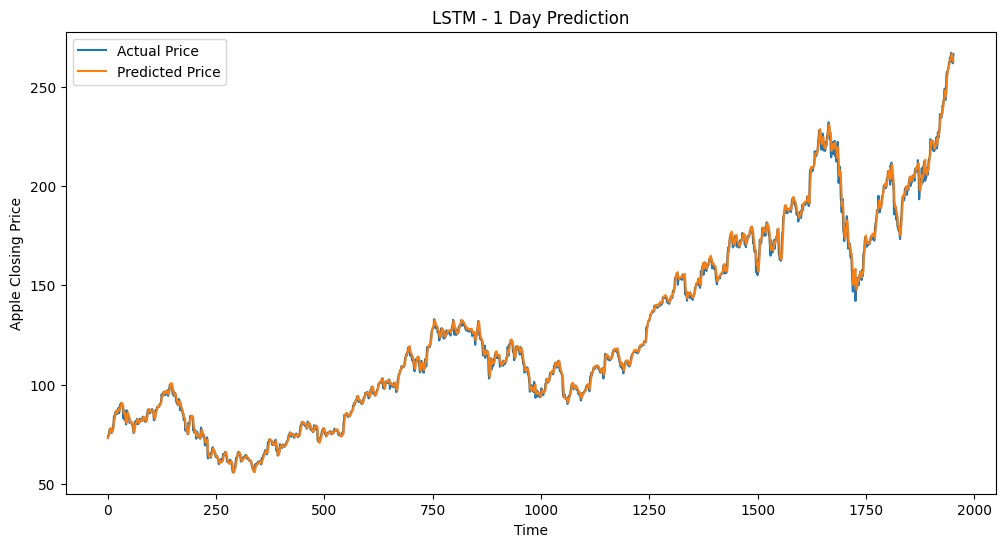


SimpleRNN MODEL - 5 DAY PREDICTION
Epoch 1/50
240/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0017
Epoch 1: val_loss improved from None to 0.04264, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 4.6174e-04 - val_loss: 0.0426
Epoch 2/50
242/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.0533e-05
Epoch 2: val_loss improved from 0.04264 to 0.01767, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 6.7843e-05 - val_loss: 0.0177
Epoch 3/50
241/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.0229e-05
Epoch 3: val_loss improved from 0.01767 to 0.01105, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 5.8244e-05 - val_loss: 0.0111
Epoch 4/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 5.5453e-05
Epoch 4: val_loss improved from 

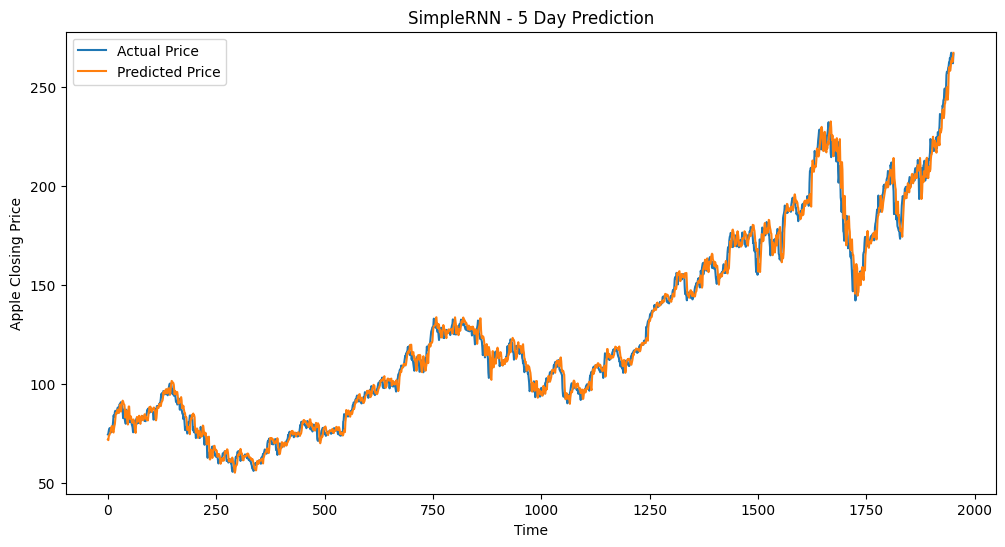


LSTM MODEL - 5 DAY PREDICTION
Epoch 1/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 4.0715e-04
Epoch 1: val_loss improved from None to 0.00290, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - loss: 1.3212e-04 - val_loss: 0.0029
Epoch 2/50
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 3.3650e-05
Epoch 2: val_loss improved from 0.00290 to 0.00073, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - loss: 2.8558e-05 - val_loss: 7.2532e-04
Epoch 3/50
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.0193e-05
Epoch 3: val_loss improved from 0.00073 to 0.00049, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 2.9310e-05 - val_loss: 4.9056e-04
Epoch 4/50
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 2.5467e-05
Epoch 4: val_loss did not

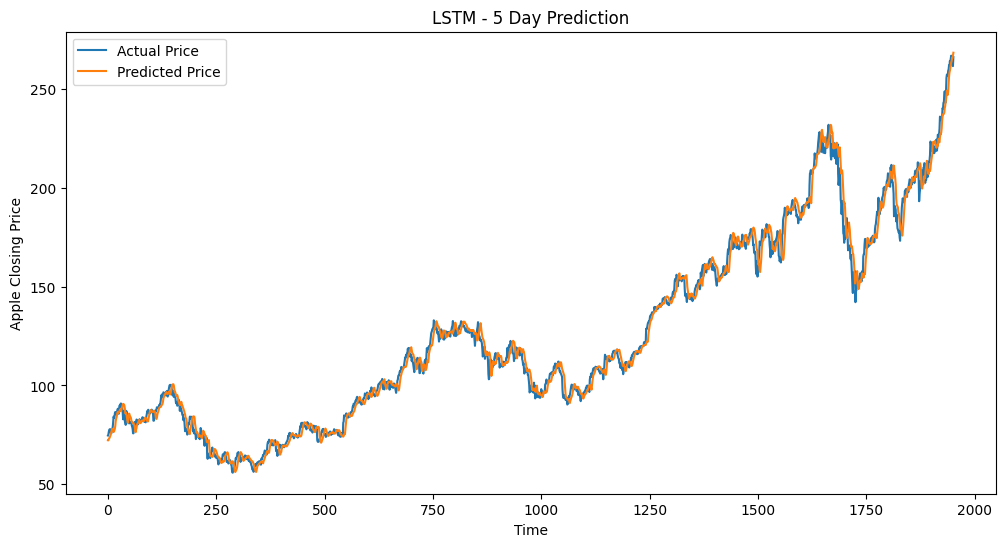


SimpleRNN MODEL - 10 DAY PREDICTION
Epoch 1/50
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.5136e-04
Epoch 1: val_loss improved from None to 0.02617, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 2.4005e-04 - val_loss: 0.0262
Epoch 2/50
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 7.9489e-05
Epoch 2: val_loss improved from 0.02617 to 0.00842, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 6.9763e-05 - val_loss: 0.0084
Epoch 3/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.1233e-05
Epoch 3: val_loss improved from 0.00842 to 0.00404, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 5.1055e-05 - val_loss: 0.0040
Epoch 4/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.9746e-05
Epoch 4: val_loss improved 

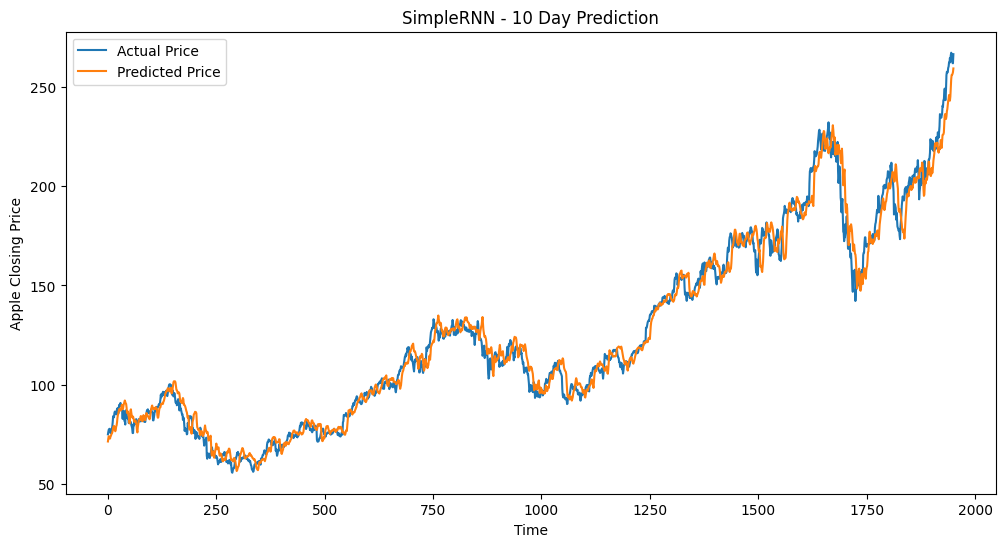


LSTM MODEL - 10 DAY PREDICTION
Epoch 1/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 3.0974e-04
Epoch 1: val_loss improved from None to 0.00135, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 1.1147e-04 - val_loss: 0.0014
Epoch 2/50
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 4.1963e-05
Epoch 2: val_loss improved from 0.00135 to 0.00095, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 4.3122e-05 - val_loss: 9.5471e-04
Epoch 3/50
243/244 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.4076e-05
Epoch 3: val_loss improved from 0.00095 to 0.00080, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 3.2811e-05 - val_loss: 8.0064e-04
Epoch 4/50
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 3.6620e-05
Epoch 4: val_loss did n

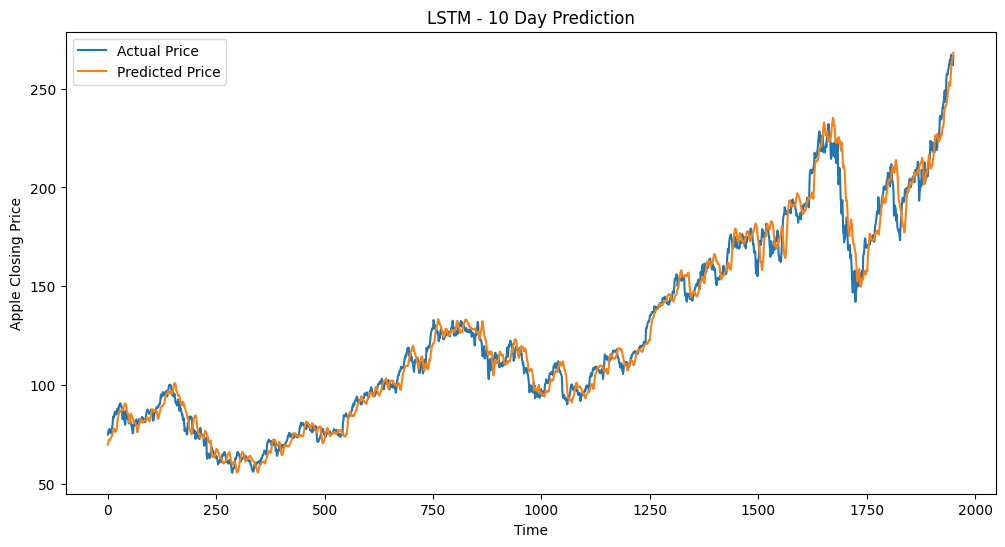

In [ ]:
results = []

def train_and_evaluate(model_type, future_days):

    print("\n" + "="*60)
    print(f"{model_type} MODEL - {future_days} DAY PREDICTION")
    print("="*60)

    # Prepare Data
    X_train, X_test, y_train, y_test = prepare_data(future_days)

    # --------------------------------------------------------
    # CALLBACKS
    # --------------------------------------------------------

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    checkpoint = ModelCheckpoint(
        "best_model.keras",    
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    # --------------------------------------------------------
    # BUILD MODEL
    # --------------------------------------------------------

    if model_type == "SimpleRNN":

        model = build_simple_rnn()

    else:

        best_params = grid_result.best_params_

        model = build_lstm(
            units=best_params['model__units'],
            dropout_rate=best_params['model__dropout_rate'],
            learning_rate=best_params['model__learning_rate']
        )

    # --------------------------------------------------------
    # TRAIN MODEL
    # --------------------------------------------------------

    history = model.fit(

        X_train, 
        y_train,

        validation_data=(X_test, y_test),

        epochs=50,

        batch_size=32,

        callbacks=[early_stop, checkpoint],

        verbose=1
    )

    # --------------------------------------------------------
    # PREDICTION
    # --------------------------------------------------------

    predictions = model.predict(X_test)

    # Inverse Scaling
    predictions = scaler.inverse_transform(predictions)

    y_test_actual = scaler.inverse_transform(
        y_test.reshape(-1, 1)
    )

    # --------------------------------------------------------
    # EVALUATION
    # --------------------------------------------------------

    mse = mean_squared_error(
        y_test_actual,
        predictions
    )

    print(f"{model_type} MSE: {mse}")


    # Store Results
    results.append({
        'Model': model_type,
        'Prediction Days': future_days,
        'MSE': mse
    })

    # --------------------------------------------------------
    # VISUALIZATION
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))

    plt.plot(
        y_test_actual,
        label='Actual Price'
    )

    plt.plot(
        predictions,
        label='Predicted Price'
    )

    plt.title(
        f'{model_type} - {future_days} Day Prediction'
    )

    plt.xlabel("Time")

    plt.ylabel("Apple Closing Price")

    plt.legend()

    plt.show()

# TRAIN MODELS
# 1 Day
train_and_evaluate("SimpleRNN", 1)
train_and_evaluate("LSTM", 1)

# 5 Days
train_and_evaluate("SimpleRNN", 5)
train_and_evaluate("LSTM", 5)

# 10 Days
train_and_evaluate("SimpleRNN", 10)
train_and_evaluate("LSTM", 10)

                            COMPARE PERFORMANCE 

In [22]:
results_df = pd.DataFrame(results)

print("\nModel Comparison")
print(results_df)


Model Comparison
       Model  Prediction Days        MSE
0  SimpleRNN                1   6.051769
1       LSTM                1   6.042143
2  SimpleRNN                5  21.967795
3       LSTM                5  23.200598
4  SimpleRNN               10  47.213913
5       LSTM               10  48.377016


                            BEST MODEL 

In [24]:
# Calculate average MSE for each model
overall_performance = results_df.groupby('Model')['MSE'].mean()

# Get model with lowest average MSE
best_model = overall_performance.idxmin()

print("\nBest Overall Model:")
print(best_model)

print("\nAverage MSE:")
print(overall_performance)


Best Overall Model:
SimpleRNN

Average MSE:
Model
LSTM         25.873252
SimpleRNN    25.077826
Name: MSE, dtype: float64
